In [1]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, ParameterEstimator
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference.CausalInference import CausalInference
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BicScore
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import daft
from daft import PGM

import sys
import psutil
import os

/opt/homebrew/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

# Load the Excel file into a DataFrame
file_path = 'Long_COVID_Dataset_AIIMS_BBSR (1).xlsx'
lc1 = pd.read_excel(file_path, sheet_name='Follow-up at 4 weeks')  # Replace 'Sheet1' with the actual sheet name
lc2=pd.read_excel(file_path, sheet_name='Follow-up at 6 months')


In [3]:
lc1.isna().sum()

participant_id             0
date_diff_four             0
age                        0
sex                        0
education                  0
occupation                 0
occupation_covid           0
height                     3
weight                     3
substance_use              0
smoking                  433
tobacco                  433
alcohol                  433
drugs                    433
past_history_covid         0
diabetes                   0
hypertension               0
anxiety                    0
depression                 0
asthma                     0
tb                         0
cancer                     0
other_medical            434
vaccine_dose_four          0
vaccine_type_four        119
vaccine_aefi_four        119
acute_symptoms             0
acute_symptoms_count       0
ct_egene_ngene            43
ct_orf1a_b_n2gene         72
covid_severity             0
covid_care                 0
longcovid_four             0
lc_fatigue_four          345
lc_cough_four 

In [4]:
lc1.head()

,participant_id,date_diff_four,age,sex,education,occupation,occupation_covid,height,weight,substance_use,...,lc_brainfog_four,lc_chestpain_four,lc_palpitation_four,lc_anxiety_four,lc_depression_four,lc_fever_four,lc_other_four,lc_activitylimit_four,lc_consultation_four,lc_hospitalized_four
0,LC001,42,29,Male,Post graduation & above,Professional / Technical / Administrative / Ma...,No,167.0,67.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LC002,42,35,Male,Post graduation & above,Professional / Technical / Administrative / Ma...,No,165.0,80.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LC003,42,22,Female,College graduate,Unemployed / Student / Homemaker,No,162.0,53.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LC004,42,23,Female,College graduate,Professional / Technical / Administrative / Ma...,Yes,153.0,60.0,No,...,No,No,No,No,No,No,Yes,No activity limitation,No,No
4,LC005,43,22,Female,10th standard or below,Unemployed / Student / Homemaker,No,142.0,50.0,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:

lc1drop=[0,5,10,11,12,22,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48]
lc1 = lc1.drop(lc1.columns[lc1drop], axis=1)

In [6]:
lc1.columns

Index(['date_diff_four', 'age', 'sex', 'education', 'occupation_covid',
       'height', 'weight', 'substance_use', 'drugs', 'past_history_covid',
       'diabetes', 'hypertension', 'anxiety', 'depression', 'asthma', 'tb',
       'cancer', 'vaccine_dose_four', 'vaccine_type_four', 'vaccine_aefi_four',
       'acute_symptoms', 'acute_symptoms_count', 'ct_egene_ngene',
       'ct_orf1a_b_n2gene', 'covid_severity', 'covid_care', 'longcovid_four'],
      dtype='object')

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)

In [8]:
# Create a DataFrame with binary encoding for the presence of each value
binary_comments =lc1['acute_symptoms'].str.get_dummies(sep=',')

In [9]:
#deleting spaces before column names
binary_comments.columns = [col.lstrip() for col in binary_comments.columns]
#checking stats
#binary_comments.sum().sort_values(ascending=False)

In [10]:
binary_comments = binary_comments.sort_index(axis=1)
binary_comments.head(2)

,Bodyache,Bodyache,Breathing difficulty,Breathing difficulty,Cold,Constipation,Cough,Cough,Diarrhoea,Diarrhoea,Diarrhoea,Fever,Fever,Headache,Headache,Headache reeling,Loss of smell,Loss of smell,Loss of taste,Loss of taste,NO SYMPTOMS,Nasal congestion,Nasal congestion,Nasal congestion,Retro orbital pain,Running nose,Running nose,Sneezing,Sore throat,Sore throat,Sudden collapse,Tiredness,Tiredness,Vomiting,Vomiting,Wheezing,blood in stools,chest pain,cold,headache,headache,headche,headreeling,hoarseness of voice,loss of appetite,pain in eyes,vomiting
0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
headache_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'Head' in col_name]
binary_comments['Headache'] = binary_comments.iloc[:, headache_cols].any(axis=1).astype(int)

# Delete the columns compared
#binary_comments.drop(binary_comments.columns[headache_cols], axis=1, inplace=True)


In [12]:
binary_comments.head(2)

,Bodyache,Bodyache,Breathing difficulty,Breathing difficulty,Cold,Constipation,Cough,Cough,Diarrhoea,Diarrhoea,Diarrhoea,Fever,Fever,Headache,Headache,Headache reeling,Loss of smell,Loss of smell,Loss of taste,Loss of taste,NO SYMPTOMS,Nasal congestion,Nasal congestion,Nasal congestion,Retro orbital pain,Running nose,Running nose,Sneezing,Sore throat,Sore throat,Sudden collapse,Tiredness,Tiredness,Vomiting,Vomiting,Wheezing,blood in stools,chest pain,cold,headache,headache,headche,headreeling,hoarseness of voice,loss of appetite,pain in eyes,vomiting
0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
headache_cols2 = [i for i, col_name in enumerate(binary_comments.columns) if 'head' in col_name]
binary_comments['headache'].sum()

#Delete the columns compared
#binary_comments.drop(binary_comments.columns[headache_cols2], axis=1, inplace=True)

headache    1
headache    2
dtype: int64

In [14]:
binary_comments.columns

Index(['Bodyache', 'Bodyache', 'Breathing difficulty', 'Breathing difficulty',
       'Cold', 'Constipation', 'Cough', 'Cough', 'Diarrhoea', 'Diarrhoea ',
       'Diarrhoea ', 'Fever', 'Fever', 'Headache', 'Headache',
       'Headache reeling', 'Loss of smell', 'Loss of smell', 'Loss of taste',
       'Loss of taste', 'NO SYMPTOMS ', 'Nasal congestion',
       'Nasal congestion ', 'Nasal congestion ', 'Retro orbital pain',
       'Running nose', 'Running nose', 'Sneezing', 'Sore throat',
       'Sore throat', 'Sudden collapse', 'Tiredness', 'Tiredness', 'Vomiting',
       'Vomiting', 'Wheezing ', 'blood in stools', 'chest pain', 'cold',
       'headache', 'headache', 'headche', 'headreeling', 'hoarseness of voice',
       'loss of appetite', 'pain in eyes', 'vomiting'],
      dtype='object')

In [15]:
drop_this=['Headache reeling','NO SYMPTOMS ','headreeling','headche']
binary_comments=binary_comments.drop(columns=drop_this)

In [16]:
binary_comments.columns

Index(['Bodyache', 'Bodyache', 'Breathing difficulty', 'Breathing difficulty',
       'Cold', 'Constipation', 'Cough', 'Cough', 'Diarrhoea', 'Diarrhoea ',
       'Diarrhoea ', 'Fever', 'Fever', 'Headache', 'Headache', 'Loss of smell',
       'Loss of smell', 'Loss of taste', 'Loss of taste', 'Nasal congestion',
       'Nasal congestion ', 'Nasal congestion ', 'Retro orbital pain',
       'Running nose', 'Running nose', 'Sneezing', 'Sore throat',
       'Sore throat', 'Sudden collapse', 'Tiredness', 'Tiredness', 'Vomiting',
       'Vomiting', 'Wheezing ', 'blood in stools', 'chest pain', 'cold',
       'headache', 'headache', 'hoarseness of voice', 'loss of appetite',
       'pain in eyes', 'vomiting'],
      dtype='object')

In [17]:
binary_comments1 = pd.DataFrame()

# Iterate through the unique column names
unique_columns = binary_comments.columns.unique()
for col in unique_columns:
    # Filter columns with the same name
    cols_with_same_name = [c for c in binary_comments.columns if c == col]
    
    # Use the bitwise OR operation to combine columns with the same name
    combined_col = binary_comments[cols_with_same_name].max(axis=1)
    
    # Store the combined column in the new DataFrame
    binary_comments1[col] = combined_col

# Resulting DataFrame will have the combined columns
binary_comments1.head(1)

,Bodyache,Breathing difficulty,Cold,Constipation,Cough,Diarrhoea,Diarrhoea,Fever,Headache,Loss of smell,Loss of taste,Nasal congestion,Nasal congestion,Retro orbital pain,Running nose,Sneezing,Sore throat,Sudden collapse,Tiredness,Vomiting,Wheezing,blood in stools,chest pain,cold,headache,hoarseness of voice,loss of appetite,pain in eyes,vomiting
0,1,1,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [18]:
binary_comments1['Diarrhoea1'] = binary_comments1[['Diarrhoea', 'Diarrhoea']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)


drop_this=['Diarrhoea','Diarrhoea']
binary_comments1=binary_comments1.drop(columns=drop_this)

In [19]:
binary_comments1['Nasal congestion1'] = binary_comments1[['Nasal congestion', 'Nasal congestion']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)


drop_this=['Nasal congestion','Nasal congestion']
binary_comments1=binary_comments1.drop(columns=drop_this)

In [20]:
binary_comments1['Cold1'] = binary_comments1[['cold', 'Cold']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)


drop_this=['cold','Cold']
binary_comments1=binary_comments1.drop(columns=drop_this)

In [21]:
binary_comments1['Headache1'] = binary_comments1[['headache', 'Headache']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)


drop_this=['headache','Headache']
binary_comments1=binary_comments1.drop(columns=drop_this)

In [22]:
binary_comments1.head(2)

,Bodyache,Breathing difficulty,Constipation,Cough,Diarrhoea,Fever,Loss of smell,Loss of taste,Nasal congestion,Retro orbital pain,Running nose,Sneezing,Sore throat,Sudden collapse,Tiredness,Vomiting,Wheezing,blood in stools,chest pain,hoarseness of voice,loss of appetite,pain in eyes,vomiting,Diarrhoea1,Nasal congestion1,Cold1,Headache1
0,1,1,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [23]:
binary_comments1.isna().sum()

Bodyache                0
Breathing difficulty    0
Constipation            0
Cough                   0
Diarrhoea               0
Fever                   0
Loss of smell           0
Loss of taste           0
Nasal congestion        0
Retro orbital pain      0
Running nose            0
Sneezing                0
Sore throat             0
Sudden collapse         0
Tiredness               0
Vomiting                0
Wheezing                0
blood in stools         0
chest pain              0
hoarseness of voice     0
loss of appetite        0
pain in eyes            0
vomiting                0
Diarrhoea1              0
Nasal congestion1       0
Cold1                   0
Headache1               0
dtype: int64

In [24]:
lc1.columns

Index(['date_diff_four', 'age', 'sex', 'education', 'occupation_covid',
       'height', 'weight', 'substance_use', 'drugs', 'past_history_covid',
       'diabetes', 'hypertension', 'anxiety', 'depression', 'asthma', 'tb',
       'cancer', 'vaccine_dose_four', 'vaccine_type_four', 'vaccine_aefi_four',
       'acute_symptoms', 'acute_symptoms_count', 'ct_egene_ngene',
       'ct_orf1a_b_n2gene', 'covid_severity', 'covid_care', 'longcovid_four'],
      dtype='object')

In [25]:
longcovid_1=pd.merge(lc1, binary_comments1, how='outer', left_index=True, right_index=True, suffixes=('_initial', '_comment'))

In [26]:
#Age ranges
age_groups = {
   
    range(13, 25): 0,
    range(25, 45): 1,
    range(45, 66): 2,
    range(66, 120): 3
}

# encode the age column
longcovid_1['Age_group'] =longcovid_1['age'].map(lambda Age: next((a for b, a in age_groups.items() if Age in b), None))

In [27]:
longcovid_1.head(3)

,date_diff_four,age,sex,education,occupation_covid,height,weight,substance_use,drugs,past_history_covid,diabetes,hypertension,anxiety,depression,asthma,tb,cancer,vaccine_dose_four,vaccine_type_four,vaccine_aefi_four,acute_symptoms,acute_symptoms_count,ct_egene_ngene,ct_orf1a_b_n2gene,covid_severity,covid_care,longcovid_four,Bodyache,Breathing difficulty,Constipation,Cough,Diarrhoea,Fever,Loss of smell,Loss of taste,Nasal congestion,Retro orbital pain,Running nose,Sneezing,Sore throat,Sudden collapse,Tiredness,Vomiting,Wheezing,blood in stools,chest pain,hoarseness of voice,loss of appetite,pain in eyes,vomiting,Diarrhoea1,Nasal congestion1,Cold1,Headache1,Age_group
0,42,29,Male,Post graduation & above,No,167.0,67.0,No,NaN,Yes,No,No,No,No,No,No,No,Yes - Two doses,Covaxin,Yes - Mild,"Fever, Cough, Bodyache, Breathing difficulty, ...",6,30,29,Mild/Moderate - Did not receive oxygen,Home isolation,NO (End of Data Collection),1,1,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
1,42,35,Male,Post graduation & above,No,165.0,80.0,No,NaN,No,No,No,No,No,No,No,No,Yes - Two doses,Covaxin,No,"Loss of smell, Loss of taste",2,NaN,NaN,Mild/Moderate - Did not receive oxygen,Home isolation,NO (End of Data Collection),0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,42,22,Female,College graduate,No,162.0,53.0,No,NaN,No,No,No,No,No,No,No,No,Yes - Two doses,Covaxin,No,Cold,1,23,NaN,Mild/Moderate - Did not receive oxygen,Home isolation,NO (End of Data Collection),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [28]:
longcovid_1.describe()

,date_diff_four,age,height,weight,acute_symptoms_count,Bodyache,Breathing difficulty,Constipation,Cough,Diarrhoea,Fever,Loss of smell,Loss of taste,Nasal congestion,Retro orbital pain,Running nose,Sneezing,Sore throat,Sudden collapse,Tiredness,Vomiting,Wheezing,blood in stools,chest pain,hoarseness of voice,loss of appetite,pain in eyes,vomiting,Diarrhoea1,Nasal congestion1,Cold1,Headache1,Age_group
count,487.000000,487.000000,484.000000,484.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000
mean,43.012320,38.971253,162.231405,62.797521,2.197125,0.182752,0.160164,0.002053,0.453799,0.026694,0.648871,0.131417,0.133470,0.047228,0.002053,0.082136,0.002053,0.102669,0.002053,0.133470,0.010267,0.002053,0.002053,0.004107,0.002053,0.002053,0.002053,0.004107,0.002053,0.006160,0.014374,0.030801,1.217659
std,6.521557,15.086281,8.202419,10.312122,1.971544,0.386860,0.367135,0.045314,0.498373,0.161353,0.477814,0.338203,0.340432,0.212344,0.045314,0.274853,0.045314,0.303839,0.045314,0.340432,0.100908,0.045314,0.045314,0.064018,0.045314,0.045314,0.045314,0.064018,0.045314,0.078325,0.119148,0.172955,0.815145
min,28.000000,18.000000,140.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,26.500000,155.000000,56.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,44.000000,35.000000,163.000000,62.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,47.000000,50.500000,168.000000,69.250000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,73.000000,88.000000,184.000000,103.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [29]:
longcovid_1.var()

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_74853/3716295709.py:1: FutureWarning: The default value of numeric_only in DataFrame.var is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  longcovid_1.var()


date_diff_four           42.530712
age                     227.595880
height                   67.279674
weight                  106.339870
acute_symptoms_count      3.886988
Bodyache                  0.149661
Breathing difficulty      0.134788
Constipation              0.002053
Cough                     0.248375
Diarrhoea                 0.026035
Fever                     0.228306
Loss of smell             0.114381
Loss of taste             0.115894
Nasal congestion          0.045090
Retro orbital pain        0.002053
Running nose              0.075544
Sneezing                  0.002053
Sore throat               0.092318
Sudden collapse           0.002053
Tiredness                 0.115894
Vomiting                  0.010182
Wheezing                  0.002053
blood in stools           0.002053
chest pain                0.004098
hoarseness of voice       0.002053
loss of appetite          0.002053
pain in eyes              0.002053
vomiting                  0.004098
Diarrhoea1          

In [30]:
longcovid_1['depression'].unique()

array(['No'], dtype=object)

In [31]:
# Define mapping dictionaries for each categorical variable
gender_mapping = {'Female': 0, 'Male': 1}
diabetes_mapping = {'No': 0, 'Yes': 1}
hypertension_mapping = {'No': 0, 'Yes': 1}
anxiety_mapping = {'No': 0, 'Yes': 1}
depression_mapping = {'No': 0, 'Yes': 1}
asthma_mapping = {'No': 0, 'Yes': 1}
tb_mapping = {'No': 0, 'Yes': 1}
cancer_mapping = {'No': 0, 'Yes': 1}
vaccine_type_mapping = {'Covaxin': 0, 'Covishield': 1}
education_mapping = {
    'Post graduation & above': 0,
    'College graduate': 1,
    '10th standard or below': 2,
    'Higher Secondary (11 to 12th standard)': 3,
    'Illiterate / No formal schooling': 4
}
occupation_covid_mapping = {'No': 0, 'Yes': 1}
past_history_covid_mapping = {'No': 0, 'Yes': 1}
covid_severity_mapping = {
    'Mild/Moderate - Did not receive oxygen': 0,
    'Severe - Received oxygen or was told you require oxygen': 1,
    'Critical - Received invasive ventilation': 2
}
longcovid_four_mapping = {'NO (End of Data Collection)': 0, 'YES - Not severe': 1, 'YES - Severe': 2}
vaccine_dose_four_mapping = {'Yes - Two doses': 2, 'Yes - Only first dose': 1, 'No': 0}
covid_care_mapping = {'Home isolation': 0, 'Admitted to hospital': 1}
vaccine_aefi_four_mapping = {'Yes - Mild': 0, 'No': 1, 'Yes - Moderate - Consulted a doctor': 2, 'Yes - Severe and Hospital admission': 3}
substance_use_mapping = {'No': 0, 'Yes': 1}

# Apply mapping to the respective columns
longcovid_1['sex'] = longcovid_1['sex'].map(gender_mapping)
longcovid_1['diabetes'] = longcovid_1['diabetes'].map(diabetes_mapping)
longcovid_1['hypertension'] = longcovid_1['hypertension'].map(hypertension_mapping)
longcovid_1['anxiety'] = longcovid_1['anxiety'].map(anxiety_mapping)
longcovid_1['depression'] = longcovid_1['depression'].map(depression_mapping)
longcovid_1['asthma'] = longcovid_1['asthma'].map(asthma_mapping)
longcovid_1['tb'] = longcovid_1['tb'].map(tb_mapping)
longcovid_1['cancer'] = longcovid_1['cancer'].map(cancer_mapping)
longcovid_1['vaccine_type_four'] = longcovid_1['vaccine_type_four'].map(vaccine_type_mapping)
longcovid_1['education'] = longcovid_1['education'].map(education_mapping)
longcovid_1['occupation_covid'] = longcovid_1['occupation_covid'].map(occupation_covid_mapping)
longcovid_1['past_history_covid'] = longcovid_1['past_history_covid'].map(past_history_covid_mapping)
longcovid_1['covid_severity'] = longcovid_1['covid_severity'].map(covid_severity_mapping)
longcovid_1['longcovid_four'] = longcovid_1['longcovid_four'].map(longcovid_four_mapping)
longcovid_1['vaccine_dose_four'] = longcovid_1['vaccine_dose_four'].map(vaccine_dose_four_mapping)
longcovid_1['covid_care'] = longcovid_1['covid_care'].map(covid_care_mapping)
longcovid_1['vaccine_aefi_four'] = longcovid_1['vaccine_aefi_four'].map(vaccine_aefi_four_mapping)
longcovid_1['substance_use'] = longcovid_1['substance_use'].map(substance_use_mapping)


In [32]:
longcovid_1.var()

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_74853/3716295709.py:1: FutureWarning: The default value of numeric_only in DataFrame.var is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  longcovid_1.var()


date_diff_four           42.530712
age                     227.595880
sex                       0.242148
education                 0.595594
occupation_covid          0.057926
height                   67.279674
weight                  106.339870
substance_use             0.098791
past_history_covid        0.035668
diabetes                  0.105128
hypertension              0.093949
anxiety                   0.006135
depression                0.000000
asthma                    0.029914
tb                        0.000000
cancer                    0.037569
vaccine_dose_four         0.716142
vaccine_type_four         0.159452
vaccine_aefi_four         0.006006
acute_symptoms_count      3.886988
covid_severity            0.148435
covid_care                0.175214
longcovid_four            0.261177
Bodyache                  0.149661
Breathing difficulty      0.134788
Constipation              0.002053
Cough                     0.248375
Diarrhoea                 0.026035
Fever               

In [33]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, ParameterEstimator
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference.CausalInference import CausalInference

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import daft
from daft import PGM

import sys
import psutil
import os

In [34]:
under = longcovid_1[[ 'diabetes', 'hypertension', 'asthma', 'cancer']].any(axis=1).astype(int)
longcovid_1['under_cond'] = under

In [35]:
bnmodel=BayesianNetwork([
#background(6)
('Age_group','longcovid_four'),('sex','longcovid_four'),( 'occupation_covid','longcovid_four')
,('substance_use','longcovid_four'),('under_cond','longcovid_four'),
#covid(2)
('covid_severity','longcovid_four'),('covid_care','longcovid_four'),('past_history_covid','longcovid_four'),
#medical conditions(6)
('diabetes','under_cond'),('hypertension','under_cond'),
('asthma','under_cond'),('cancer','under_cond'),
#vaccine(3)
('vaccine_dose_four','longcovid_four'),
#symptoms(10)
('Cold1','longcovid_four'),('Cough','longcovid_four'),('Breathing difficulty','longcovid_four'),
('Sore throat','longcovid_four'),('Headache1','longcovid_four'),('Loss of smell','longcovid_four'),('Loss of taste','longcovid_four')
,('Fever','longcovid_four'),('Diarrhoea1','longcovid_four')   
])

In [36]:
covidpgm = PGM(shape=[8,10])
covidpgm.add_node(daft.Node('sex','Gend',4,10, scale=1.5))
covidpgm.add_node(daft.Node('substance_use','Drug\nuse',4,8, scale=1.5))
covidpgm.add_node(daft.Node('Age_group','Age\nGroup',4,9, scale=1.5))
covidpgm.add_node(daft.Node('occupation_covid','job\ncovid',4,7, scale=1.5))
covidpgm.add_node(daft.Node('under_cond','Under\nCond',4,6,scale=1.5))
covidpgm.add_node(daft.Node('longcovid_four','long\nCOVID',2,5, scale=1.5))

covidpgm.add_node(daft.Node('diabetes','diabetes',6,6,scale=1.5))
covidpgm.add_node(daft.Node('hypertension','Hyper\ntension',6,4,scale=1.5))
covidpgm.add_node(daft.Node('asthma','asthma',6,3,scale=1.5))
covidpgm.add_node(daft.Node('cancer','cancer',6,1,scale=1.5))

covidpgm.add_node(daft.Node('covid_severity','covid\nseverity',0,1,scale=1.5))
covidpgm.add_node(daft.Node('covid_care','covid\ncare',1,1,scale=1.5))
covidpgm.add_node(daft.Node('past_history_covid','covid\nhistory',2,1,scale=1.5))


covidpgm.add_node(daft.Node('vaccine_dose_four','vaccine\nweek4',5,1,scale=1.5))
covidpgm.add_node(daft.Node('vaccine_type_four','vaccine\ntype',3,1,scale=1.5))
covidpgm.add_node(daft.Node('vaccine_aefi_four','vaccine\neffect',4,1,scale=1.5))




covidpgm.add_node(daft.Node('Cold1','Cold',0,3,scale=1.5))
covidpgm.add_node(daft.Node('Cough','Cough',0,4,scale=1.5))
covidpgm.add_node(daft.Node('Sore throat','Sore\nthroat',0,5,scale=1.5))
covidpgm.add_node(daft.Node('Headache1','Headache',0,6,scale=1.5))
covidpgm.add_node(daft.Node('Breathing difficulty','Breathing\ndifficulty',0,7,scale=1.5))
covidpgm.add_node(daft.Node('Loss of smell','Anosmia',0,8,scale=1.5))
covidpgm.add_node(daft.Node('Loss of taste','Ageusia',0,9,scale=1.5))
covidpgm.add_node(daft.Node('Diarrhoea1','Diarrhoea',0,10,scale=1.5))

covidpgm.add_node(daft.Node('Fever','Fever',2,10,scale=1.5))


In [37]:
covidpgm.add_edge('sex','longcovid_four')
covidpgm.add_edge('substance_use','longcovid_four')
covidpgm.add_edge('Age_group','longcovid_four')
covidpgm.add_edge('occupation_covid','longcovid_four')
covidpgm.add_edge('under_cond','longcovid_four')


covidpgm.add_edge('diabetes','under_cond')
covidpgm.add_edge('hypertension','under_cond')
covidpgm.add_edge('asthma','under_cond')
covidpgm.add_edge('cancer','under_cond')

covidpgm.add_edge('covid_severity','longcovid_four')
covidpgm.add_edge('covid_care','longcovid_four')
covidpgm.add_edge('past_history_covid','longcovid_four')


covidpgm.add_edge('vaccine_dose_four','longcovid_four')
covidpgm.add_edge('vaccine_type_four','longcovid_four')
covidpgm.add_edge('vaccine_aefi_four','longcovid_four')




covidpgm.add_edge('Cold1','longcovid_four')
covidpgm.add_edge('Cough','longcovid_four')
covidpgm.add_edge('Sore throat','longcovid_four')
covidpgm.add_edge('Headache1','longcovid_four')
covidpgm.add_edge('Breathing difficulty','longcovid_four')
covidpgm.add_edge('Loss of smell','longcovid_four')
covidpgm.add_edge('Loss of taste','longcovid_four')
covidpgm.add_edge('Diarrhoea1','longcovid_four')

covidpgm.add_edge('Fever','longcovid_four')


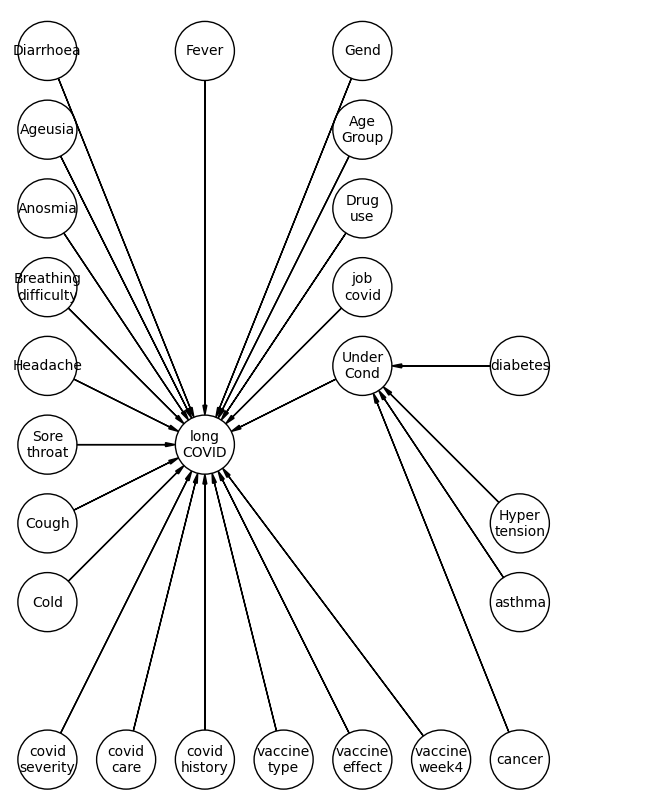

In [38]:
covidpgm.render()
plt.show()

In [39]:
longcovid_1.columns

Index(['date_diff_four', 'age', 'sex', 'education', 'occupation_covid',
       'height', 'weight', 'substance_use', 'drugs', 'past_history_covid',
       'diabetes', 'hypertension', 'anxiety', 'depression', 'asthma', 'tb',
       'cancer', 'vaccine_dose_four', 'vaccine_type_four', 'vaccine_aefi_four',
       'acute_symptoms', 'acute_symptoms_count', 'ct_egene_ngene',
       'ct_orf1a_b_n2gene', 'covid_severity', 'covid_care', 'longcovid_four',
       'Bodyache', 'Breathing difficulty', 'Constipation', 'Cough',
       'Diarrhoea ', 'Fever', 'Loss of smell', 'Loss of taste',
       'Nasal congestion ', 'Retro orbital pain', 'Running nose', 'Sneezing',
       'Sore throat', 'Sudden collapse', 'Tiredness', 'Vomiting', 'Wheezing ',
       'blood in stools', 'chest pain', 'hoarseness of voice',
       'loss of appetite', 'pain in eyes', 'vomiting', 'Diarrhoea1',
       'Nasal congestion1', 'Cold1', 'Headache1', 'Age_group', 'under_cond'],
      dtype='object')

In [40]:
longcovid_1=longcovid_1.loc[:,['Age_group', 'longcovid_four', 'sex', 'occupation_covid', 'substance_use', 'under_cond', 'covid_severity', 'covid_care', 'past_history_covid', 'diabetes', 'hypertension', 'asthma', 'cancer', 'vaccine_dose_four','Cold1', 'Cough', 'Breathing difficulty', 'Sore throat', 'Headache1', 'Loss of smell', 'Loss of taste', 'Fever', 'Diarrhoea1']]

In [41]:
Hypercpd = TabularCPD(variable='hypertension',
                       variable_card=2,
                       values=[[0.34], [.66]]) #AIHW 34%
Diabcpd = TabularCPD(variable='diabetes',
                       variable_card=2,
                       values=[[.049], [.951]]) #AIHW 4.9%
Asthmacpd = TabularCPD(variable='asthma',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%

cancercpd = TabularCPD(variable='cancer',
                       variable_card=2,
                       values=[[.43], [.57]]) #union from AIHW 19.6%



sexcpd = TabularCPD(variable='sex',
                       variable_card=2,
                       values=[[.5021], [.4979]]) #from ABS population
Agecpd = TabularCPD(variable='Age_group', #from ABS 
                       variable_card=4,
                       values=[ [.25], [0.25], [0.25], [0.25]])
Subcpd = TabularCPD(variable='substance_use',
                       variable_card=2,
                       values=[[.042], [.958]]) #AIHW 11%



Coldcpd = TabularCPD(variable='Cold1',
                       variable_card=2,
                       values=[[.125], [.875]]) #20% on winters
Coughcpd = TabularCPD(variable='Cough',
                       variable_card=2,
                       values=[[.1], [.9]])
BDcpd = TabularCPD(variable='Breathing difficulty',
                       variable_card=2,
                       values=[[.075], [.925]])
Headachecpd = TabularCPD(variable='Headache1',
                       variable_card=2,
                       values=[[.15], [.85]])
Sorethroatcpd = TabularCPD(variable='Sore throat',
                       variable_card=2,
                       values=[[.1], [.90]])
Fevercpd = TabularCPD(variable='Fever',
                       variable_card=2,
                       values=[[.06], [.94]])
Anosmiacpd = TabularCPD(variable='Loss of smell',
                       variable_card=2,
                       values=[[.03], [.97]])

Ageusiacpd = TabularCPD(variable='Loss of taste',
                       variable_card=2,
                       values=[[.02], [.98]])

In [42]:
bnmodel.add_cpds(Hypercpd,Diabcpd,Asthmacpd,cancercpd,sexcpd,Agecpd,Subcpd,Coldcpd,Coughcpd,BDcpd,Headachecpd,Anosmiacpd,
Ageusiacpd,Fevercpd,Sorethroatcpd) 

In [43]:
training_data, testing_data = train_test_split(longcovid_1, test_size=0.35, random_state=42)

In [44]:
training_data.head(3)

,Age_group,longcovid_four,sex,occupation_covid,substance_use,under_cond,covid_severity,covid_care,past_history_covid,diabetes,hypertension,asthma,cancer,vaccine_dose_four,Cold1,Cough,Breathing difficulty,Sore throat,Headache1,Loss of smell,Loss of taste,Fever,Diarrhoea1
228,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
265,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
204,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


In [45]:
# Bayesian Estimation on the Training Data
estimator = BayesianEstimator(bnmodel, training_data)
long_covcpd = estimator.estimate_cpd('longcovid_four')
UCcpd = estimator.estimate_cpd('under_cond')

occucpd = estimator.estimate_cpd('occupation_covid')
cov_sevcpd = estimator.estimate_cpd('covid_severity')
cov_carecpd = estimator.estimate_cpd('covid_care')
vacdose_4cpd = estimator.estimate_cpd('vaccine_dose_four')

Diarrcpd = estimator.estimate_cpd('Diarrhoea1')
cov_hiscpd = estimator.estimate_cpd('past_history_covid')


bnmodel.add_cpds(long_covcpd,UCcpd,occucpd,cov_sevcpd,cov_carecpd,
vacdose_4cpd, Diarrcpd,cov_hiscpd)

In [46]:
target = 'longcovid_four'
features = longcovid_1.drop(columns=[target])
target =longcovid_1[target]

In [51]:
for i in range(len(X_test)):
    evidence = X_test.iloc[i].to_dict()
    query = 'longcovid_four'
    print("Index:", i)
    print("Evidence:", evidence)
    print("Query:", query)
    try:
        factor = infer.query([query], evidence=evidence)
        
        predicted_class = factor.values.argmax()
        predictions.append(predicted_class)
    except KeyError as e:
        print("Error:", e)
    
    
    predicted_class = factor.values.argmax()
    predictions.append(predicted_class)


        
        
        # Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

# Create the confusion matrix
confusion_matrix_result = confusion_matrix(y_test, predictions)

# Print results
print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(confusion_matrix_result)

# Generate a classification report
classification_rep = classification_report(y_test, predictions)
print("Classification Report:")
print(classification_rep)

    

Index: 0
Evidence: {'Age_group': 1, 'sex': 1, 'occupation_covid': 0, 'substance_use': 0, 'under_cond': 0, 'covid_severity': 0, 'covid_care': 0, 'past_history_covid': 0, 'diabetes': 0, 'hypertension': 0, 'asthma': 0, 'cancer': 0, 'vaccine_dose_four': 2, 'Cold1': 0, 'Cough': 0, 'Breathing difficulty': 0, 'Sore throat': 0, 'Headache1': 0, 'Loss of smell': 0, 'Loss of taste': 0, 'Fever': 1, 'Diarrhoea1': 0}
Query: longcovid_four
Index: 1
Evidence: {'Age_group': 1, 'sex': 1, 'occupation_covid': 0, 'substance_use': 0, 'under_cond': 0, 'covid_severity': 0, 'covid_care': 0, 'past_history_covid': 0, 'diabetes': 0, 'hypertension': 0, 'asthma': 0, 'cancer': 0, 'vaccine_dose_four': 1, 'Cold1': 0, 'Cough': 0, 'Breathing difficulty': 0, 'Sore throat': 0, 'Headache1': 0, 'Loss of smell': 0, 'Loss of taste': 0, 'Fever': 0, 'Diarrhoea1': 0}
Query: longcovid_four
Index: 2
Evidence: {'Age_group': 1, 'sex': 1, 'occupation_covid': 0, 'substance_use': 0, 'under_cond': 0, 'covid_severity': 0, 'covid_care': 0

ValueError: Found input variables with inconsistent numbers of samples: [171, 652]

In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


infer = VariableElimination(bnmodel)
X_test, y_test = testing_data[features.columns], testing_data['longcovid_four']

predictions = []

# Loop through the testing data
for i in range(len(X_test)):
    evidence = X_test.iloc[i].to_dict()
    query = 'longcovid_four'
    factor = infer.query([query], evidence=evidence)
    
    # Find the class with the highest probability
    predicted_class = factor.values.argmax()
    predictions.append(predicted_class)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

# Create the confusion matrix
confusion_matrix_result = confusion_matrix(y_test, predictions)

# Print results
print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(confusion_matrix_result)

# Generate a classification report
classification_rep = classification_report(y_test, predictions)
print("Classification Report:")
print(classification_rep)


KeyError: 1

In [ ]:
long_covcpd.state_names['longcovid_four']

In [ ]:
for variable_name in bnmodel.nodes():
    cpd = bnmodel.get_cpds(variable_name)
    state_names = cpd.state_names[variable_name]
    
    print(f"State names for variable '{variable_name}':")
    print(state_names)

In [ ]:
print(bnmodel.get_cpds('longcovid_four').state_names['longcovid_four'])


In [ ]:
print(evidence)


In [48]:
testing_data['longcovid_four'].unique()

array([1, 0, 2])